Model training completed.


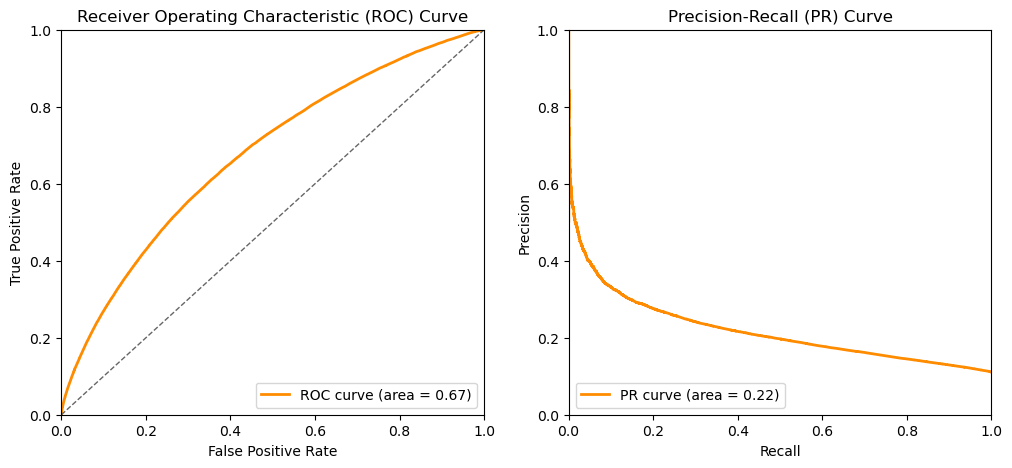

AUROC: 0.6750
AUPRC: 0.2182


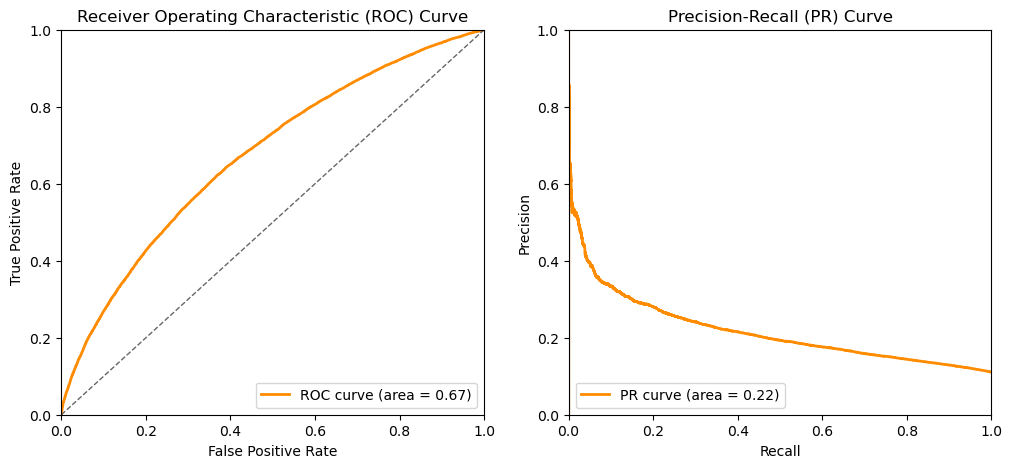

AUROC: 0.6725
AUPRC: 0.2177


[0.6725291342229867,
 0.6679075095565952,
 0.6783062233647349,
 0.8895640123654195,
 0.008815426997245178,
 0.9990412108137723,
 0.5333333333333333,
 0.8902161807557936,
 0.017344173441734417]

In [1]:
from ehr_models import *
import ehr_utils
import pandas as pd
# file_path=r'C:\Users\ydl\Desktop\ehr0528\data_cleaned\ver-noelectrolyte-logtransform_bayesian.csv'
file_path = r'C:\Users\ydl\Desktop\ehr0528\data_cleaned\ver-noelectrolyte-logtransform_mean.csv'
# file_path = r'C:\Users\ydl\Desktop\ehr0528\data_cleaned\ver-noelectrolyte-logtransform_drop.csv'

X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(file_path, train_size=0.8, random_state=42)

## 需要测试哪个模型就取消注释对应的行,需要默认参数default=True，需要优化后的参数 默认=false
default = False
model = init_adaBoost(default_parm=default)
# model = init_decisionTree(default_parm=default)
# model = init_gaussianNB(default_parm=default)
# model = init_gradientBoosting(default_parm=default)
# model = init_lightGBM(default_parm=default)
# model = init_linearDiscriminantAnalysis(default_parm=default)
# model = init_logisticRegression(default_parm=default)
# model = init_MLPClassifier(default_parm=default)
# model = init_randomForest(default_parm=default)
# model = init_XGBoost(default_parm=default)

model.fit(X_train, Y_train)
print("Model training completed.")
Y_prob, Y_pred = ehr_utils.get_prediction_results(model, X_test)
Ytrain_prob, Ytrain_pred = ehr_utils.get_prediction_results(model, X_train)
ehr_utils.plot_roc_pr_curves(Y_train, Ytrain_prob, 'dt')
ehr_utils.plot_roc_pr_curves(Y_test, Y_prob, 'xgb')
ehr_utils.eval_model(Y_test, Y_pred, Y_prob)

In [ ]:
[0.6779927147256444,
 0.671752415795094,
 0.684274159906009,
 0.8896553824599875,
 0.003581267217630854,
 0.9997945451743798,
 0.6842105263157895,
 0.8897743375641866,
 0.00712523979172376]

In [ ]:
[0.6593820797546768,
 0.6521964028537679,
 0.6645682725807092,
 0.6299663453485008,
 0.596625344352617,
 0.6341106374235965,
 0.16852774103182633,
 0.92672338296009,
 0.26281779018263457]